# Modeling with Price Features
## Repsol Capstone Project — Sprint 2 (Extension)

**Goal:** Retrain Random Forest and XGBoost models adding fuel price lag features.
Evaluate whether price context improves forecast accuracy vs the baseline models in `07_modeling.ipynb`.

**Motivation from `06_price_features.ipynb`:**
- `PVP_gasolina95_nac` lag_1 → r = -0.813 with Nacional biodiesel demand
- `PVP_gasoleo_a_nac` lag_1 → r = -0.689
- Strong negative correlation: higher conventional fuel prices → higher biodiesel adoption

**Note:** SARIMA is not retrained here. Adding exogenous price variables to SARIMAX would require
forecasting prices through 2027, which adds a full second modelling layer. Given the sample size
(36 observations), SARIMA with the log1p transformation remains the primary model.

**Inputs:**
- `data/processed/model_dataset.csv` — baseline feature matrix
- `data/processed/price_features.csv` — monthly fuel prices (national + regional, lag_1)

**Outputs:**
- `data/processed/metrics_with_prices.csv`
- `data/processed/predictions_with_prices.csv`
- `data/processed/forecast_24m_with_prices.csv`
- `data/processed/metrics_comparison.csv` — baseline vs price-augmented side by side

## 0. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)

NOTEBOOK_DIR  = Path().resolve()
REPO_ROOT     = NOTEBOOK_DIR.parent
DATA_INPUTS   = REPO_ROOT / 'data' / 'inputs'
DATA_FEATURES = REPO_ROOT / 'data' / 'features'
DATA_OUTPUTS  = REPO_ROOT / 'data' / 'outputs'
FIGS          = REPO_ROOT / 'reports' / 'figures'

TARGETS = ['Nacional', 'Madrid', 'Cataluña', 'Andalucía', 'Valencia']

# Baseline ML features (from 07_modeling). Only the _lag1 macro features are
# used -- the contemporaneous IPI_original / IPC_var_anual / Tasa_paro values
# are not actually known at forecast time (INE publishes them with a delay),
# so including them would leak look-ahead information.
ML_BASE = ['Tendencia','Mes','sin_mes','cos_mes','Lag_1','Lag_2','Lag_3',
           'Roll_mean_3','Roll_mean_6',
           'IPI_original_lag1','IPC_var_anual_lag1','Tasa_paro_lag1']

# Price suffix per target region (maps target → column suffix in price_features.csv)
TARGET_PRICE_SUFFIX = {
    'Nacional':  '_nac',
    'Madrid':    '_madrid',
    'Cataluña':  '_cataluna',
    'Andalucía': '_andalucia',
    'Valencia':  '_valencia',
}

FC_DATES = pd.date_range('2026-01', periods=24, freq='MS').strftime('%Y-%m').tolist()

df_model        = pd.read_csv(DATA_FEATURES / 'features_modelo_completo.csv')
df_prices       = pd.read_csv(DATA_FEATURES / 'features_precios_combustibles.csv')
df_metrics_base = pd.read_csv(DATA_OUTPUTS  / 'metricas_modelos.csv')
df_macro        = (
    pd.read_csv(DATA_INPUTS / 'master_dataset.csv')
    .query('CCAA == "ESPAÑA"')[['Fecha', 'IPI_original', 'IPI_ajustado', 'IPC_var_anual', 'Tasa_paro']]
    .drop_duplicates('Fecha')
    .reset_index(drop=True)
)

print('Model dataset:', df_model.shape)
print('Price features:', df_prices.shape)

Model dataset: (180, 25)
Price features: (36, 81)


## 1. Merge Price Features into Model Dataset

### What?
For each (target, month) row in the model dataset, attach the corresponding lag_1 price features:
- `PVP_gasoleo_a_<region>_lag1` — region-specific diesel price (direct substitute)
- `PVP_gasolina95_nac_lag1` — national gasoline reference price (strongest predictor overall)

### Why?
We use lag_1 (price at t-1) rather than contemporaneous price because:
1. It is causally valid — we always know last month's price when making a forecast
2. The lag_1 correlation (r ≈ -0.81) is virtually identical to the contemporaneous (r ≈ -0.82),
   meaning the price signal does not decay significantly over one month

In [2]:
# Build a minimal price join table: one row per (Fecha, Target) with the 2 price features
price_join_frames = []

for tgt, suffix in TARGET_PRICE_SUFFIX.items():
    pvp_diesel_col  = f'PVP_gasoleo_a{suffix}_lag1'
    pvp_gas95_col   = 'PVP_gasolina95_nac_lag1'   # always national (highest correlation)
    pvp_gas95_reg   = f'PVP_gasolina95{suffix}_lag1'

    sub = df_prices[['Fecha']].copy()
    sub['Target'] = tgt

    # Region-specific diesel lag_1 (fall back to national if not available)
    if pvp_diesel_col in df_prices.columns:
        sub['Precio_gasoleo_lag1'] = df_prices[pvp_diesel_col].values
    else:
        sub['Precio_gasoleo_lag1'] = df_prices['PVP_gasoleo_a_nac_lag1'].values
        print(f'  {tgt}: using national diesel price (regional not available)')

    # Gasoline 95 lag_1 (regional if available, else national)
    if pvp_gas95_reg in df_prices.columns:
        sub['Precio_gasolina_lag1'] = df_prices[pvp_gas95_reg].values
    else:
        sub['Precio_gasolina_lag1'] = df_prices[pvp_gas95_col].values

    price_join_frames.append(sub)

df_price_join = pd.concat(price_join_frames, ignore_index=True)

# Merge into model dataset
df_aug = df_model.merge(df_price_join, on=['Fecha', 'Target'], how='left')

print(f'Augmented dataset shape: {df_aug.shape}')
print(f'Null counts for new features:')
print(df_aug[['Precio_gasoleo_lag1','Precio_gasolina_lag1']].isnull().sum())
df_aug[['Fecha','Target','Precio_gasoleo_lag1','Precio_gasolina_lag1']].head(6)

  Andalucía: using national diesel price (regional not available)
Augmented dataset shape: (180, 27)
Null counts for new features:
Precio_gasoleo_lag1     5
Precio_gasolina_lag1    5
dtype: int64


,Fecha,Target,Precio_gasoleo_lag1,Precio_gasolina_lag1
0,2023-01,Andalucía,NaN,NaN
1,2023-02,Andalucía,1.674247,1.618154
2,2023-03,Andalucía,1.609868,1.622847
3,2023-04,Andalucía,1.558718,1.618254
4,2023-05,Andalucía,1.495926,1.621656
5,2023-06,Andalucía,1.413919,1.569363


In [3]:
# Extended feature list (baseline + 2 price lag features)
ML_PRICE = ML_BASE + ['Precio_gasoleo_lag1', 'Precio_gasolina_lag1']

# Temporal train/test split (same as baseline)
df_train = df_aug[df_aug['Fecha'] < '2025-01'].copy()
df_test  = df_aug[df_aug['Fecha'] >= '2025-01'].copy()

print(f'Train: {df_train.shape}, Test: {df_test.shape}')
print(f'ML features ({len(ML_PRICE)}): {ML_PRICE}')

# Last known prices for 24m forecast (hold at Dec 2025 values)
last_prices = {}
for tgt in TARGETS:
    row = df_aug[(df_aug['Target']==tgt) & (df_aug['Fecha']=='2025-12')]
    if len(row):
        last_prices[tgt] = {
            'Precio_gasoleo_lag1':  float(row['Precio_gasoleo_lag1'].iloc[0]),
            'Precio_gasolina_lag1': float(row['Precio_gasolina_lag1'].iloc[0]),
        }
    else:
        last_prices[tgt] = {'Precio_gasoleo_lag1': 1.5, 'Precio_gasolina_lag1': 1.5}

print('\nLast known prices (Dec 2025):')
for tgt, vals in last_prices.items():
    print(f'  {tgt:<12}: gasoleo={vals["Precio_gasoleo_lag1"]:.3f}  gasolina={vals["Precio_gasolina_lag1"]:.3f}')

Train: (120, 27), Test: (60, 27)
ML features (14): ['Tendencia', 'Mes', 'sin_mes', 'cos_mes', 'Lag_1', 'Lag_2', 'Lag_3', 'Roll_mean_3', 'Roll_mean_6', 'IPI_original_lag1', 'IPC_var_anual_lag1', 'Tasa_paro_lag1', 'Precio_gasoleo_lag1', 'Precio_gasolina_lag1']

Last known prices (Dec 2025):
  Nacional    : gasoleo=1.434  gasolina=1.468
  Madrid      : gasoleo=1.460  gasolina=1.504
  Cataluña    : gasoleo=1.433  gasolina=1.483
  Andalucía   : gasoleo=1.434  gasolina=1.468
  Valencia    : gasoleo=1.437  gasolina=1.492


## 2. Train & Evaluate RF + XGBoost with Price Features

In [4]:
met_out, pred_out, fc_out = [], [], []

for tgt in TARGETS:
    print(f'  {tgt}...')
    tr = df_train[df_train['Target']==tgt].sort_values('Fecha')
    te = df_test[df_test['Target']==tgt].sort_values('Fecha')

    tr_ml = tr[['Fecha'] + ML_PRICE + ['Consumo_Tm']].dropna()
    te_ml = te[['Fecha'] + ML_PRICE + ['Consumo_Tm']].dropna()

    if len(tr_ml) < 5:
        print(f'    Skipped — not enough rows after dropna')
        continue

    Xtr = tr_ml[ML_PRICE].values
    ytr = np.log1p(tr_ml['Consumo_Tm'].values)
    Xte = te_ml[ML_PRICE].values
    yte = te_ml['Consumo_Tm'].values

    sc = StandardScaler()
    Xtr_s = sc.fit_transform(Xtr)
    Xte_s = sc.transform(Xte)

    # Full series for recursive forecast initialization
    all_rows = df_aug[df_aug['Target']==tgt].sort_values('Fecha')
    y_all = all_rows['Consumo_Tm'].values
    p_gaso   = last_prices[tgt]['Precio_gasoleo_lag1']
    p_gas95  = last_prices[tgt]['Precio_gasolina_lag1']

    for lbl, mdl in [
        ('RF+Precios', RandomForestRegressor(n_estimators=300, max_depth=3,
                                             min_samples_leaf=3, random_state=42)),
        ('XGB+Precios', xgb.XGBRegressor(n_estimators=300, max_depth=2, learning_rate=0.05,
                                          subsample=0.9, reg_alpha=1, reg_lambda=5,
                                          random_state=42, verbosity=0)),
    ]:
        mdl.fit(Xtr_s, ytr)
        p = np.maximum(np.expm1(mdl.predict(Xte_s)), 0)
        mask = yte > 0
        mape = float(np.mean(np.abs((yte[mask]-p[mask])/yte[mask]))*100) if mask.sum() else float('nan')
        met_out.append({'Target': tgt, 'Model': lbl,
                        'MAE':  round(float(mean_absolute_error(yte, p)), 1),
                        'RMSE': round(float(np.sqrt(mean_squared_error(yte, p))), 1),
                        'MAPE': round(mape, 1)})
        for fd, fv, fa in zip(te_ml['Fecha'].tolist(), p.tolist(), yte.tolist()):
            pred_out.append({'Fecha': fd, 'Target': tgt, 'Model': lbl,
                             'Pred': round(fv, 1), 'Actual': round(fa, 1)})

        # Recursive 24-month forecast (hold prices at last known value)
        hist = list(y_all[-6:].tolist())
        m_last = {k: float(df_macro.iloc[-1][k]) for k in ['IPI_original','IPC_var_anual','Tasa_paro']}
        for step in range(24):
            mes   = ((36 + step) % 12) + 1
            trend = 37 + step
            l1 = float(hist[-1])
            l2 = float(hist[-2]) if len(hist) >= 2 else 0.0
            l3 = float(hist[-3]) if len(hist) >= 3 else 0.0
            r3 = float(np.mean(hist[-3:]))
            r6 = float(np.mean(hist[-6:]) if len(hist) >= 6 else np.mean(hist))
            # Build the row by feature name (keyed off ML_PRICE) rather than by
            # fixed position -- a positional array silently breaks whenever the
            # feature list changes (as happened when the leaky contemporaneous
            # macro columns were removed from ML_BASE above).
            feat_values = {
                'Tendencia': trend, 'Mes': mes,
                'sin_mes': np.sin(2 * np.pi * mes / 12),
                'cos_mes': np.cos(2 * np.pi * mes / 12),
                'Lag_1': l1, 'Lag_2': l2, 'Lag_3': l3,
                'Roll_mean_3': r3, 'Roll_mean_6': r6,
                'IPI_original_lag1': m_last['IPI_original'],
                'IPC_var_anual_lag1': m_last['IPC_var_anual'],
                'Tasa_paro_lag1': m_last['Tasa_paro'],
                'Precio_gasoleo_lag1': p_gaso,
                'Precio_gasolina_lag1': p_gas95,
            }
            row = np.array([[feat_values[f] for f in ML_PRICE]])
            pv = float(np.maximum(np.expm1(mdl.predict(sc.transform(row))[0]), 0))
            hist.append(pv)
            fc_out.append({'Fecha': FC_DATES[step], 'Target': tgt,
                           'Model': lbl, 'Forecast': round(pv, 1)})

print('\nDone.')
pd.DataFrame(met_out)

  Nacional...


  Madrid...


  Cataluña...


  Andalucía...


  Valencia...



Done.


,Target,Model,MAE,RMSE,MAPE
0,Nacional,RF+Precios,10962.8,11922.4,56.9
1,Nacional,XGB+Precios,11451.1,12361.6,59.8
2,Madrid,RF+Precios,1797.6,1910.9,64.1
3,Madrid,XGB+Precios,1710.9,1799.7,61.9
4,Cataluña,RF+Precios,1785.0,1879.2,60.4
5,Cataluña,XGB+Precios,1709.9,1802.6,57.8
6,Andalucía,RF+Precios,991.5,1172.9,57.6
7,Andalucía,XGB+Precios,1046.3,1194.4,65.1
8,Valencia,RF+Precios,568.3,632.6,59.3
9,Valencia,XGB+Precios,537.7,614.0,54.7


## 3. Compare Baseline vs Price-Augmented Models

In [5]:
# Add SARIMA baseline to the comparison (it's unchanged)
df_sarima = df_metrics_base[df_metrics_base['Model']=='SARIMA'].copy()

df_new = pd.DataFrame(met_out)
df_base_ml = df_metrics_base[df_metrics_base['Model'].isin(['Random Forest','XGBoost'])].copy()

# Rename baseline models for clarity
df_base_ml = df_base_ml.copy()
df_base_ml['Model'] = df_base_ml['Model'].map({
    'Random Forest': 'RF (baseline)',
    'XGBoost':       'XGB (baseline)'
})

df_comparison = pd.concat([df_sarima, df_base_ml, df_new], ignore_index=True)

# Pivot MAPE for easy reading
pivot = df_comparison.pivot(index='Target', columns='Model', values='MAPE').round(1)
# Compute delta vs SARIMA
for col in pivot.columns:
    pivot[f'Δ_vs_SARIMA_{col}'] = (pivot[col] - pivot['SARIMA']).round(1)

print('MAPE (%) — Baseline vs Price-Augmented vs SARIMA')
print('Lower = better')
print(pivot.to_string())

MAPE (%) — Baseline vs Price-Augmented vs SARIMA
Lower = better
Model      RF (baseline)  RF+Precios  SARIMA  XGB (baseline)  XGB+Precios  Δ_vs_SARIMA_RF (baseline)  Δ_vs_SARIMA_RF+Precios  Δ_vs_SARIMA_SARIMA  Δ_vs_SARIMA_XGB (baseline)  Δ_vs_SARIMA_XGB+Precios
Target                                                                                                                                                                                               
Andalucía           56.2        57.6    52.5            64.9         65.1                        3.7                     5.1                 0.0                        12.4                     12.6
Cataluña            59.7        60.4    47.2            61.7         57.8                       12.5                    13.2                 0.0                        14.5                     10.6
Madrid              65.2        64.1   318.7            63.1         61.9                     -253.5                  -254.6                 0.0

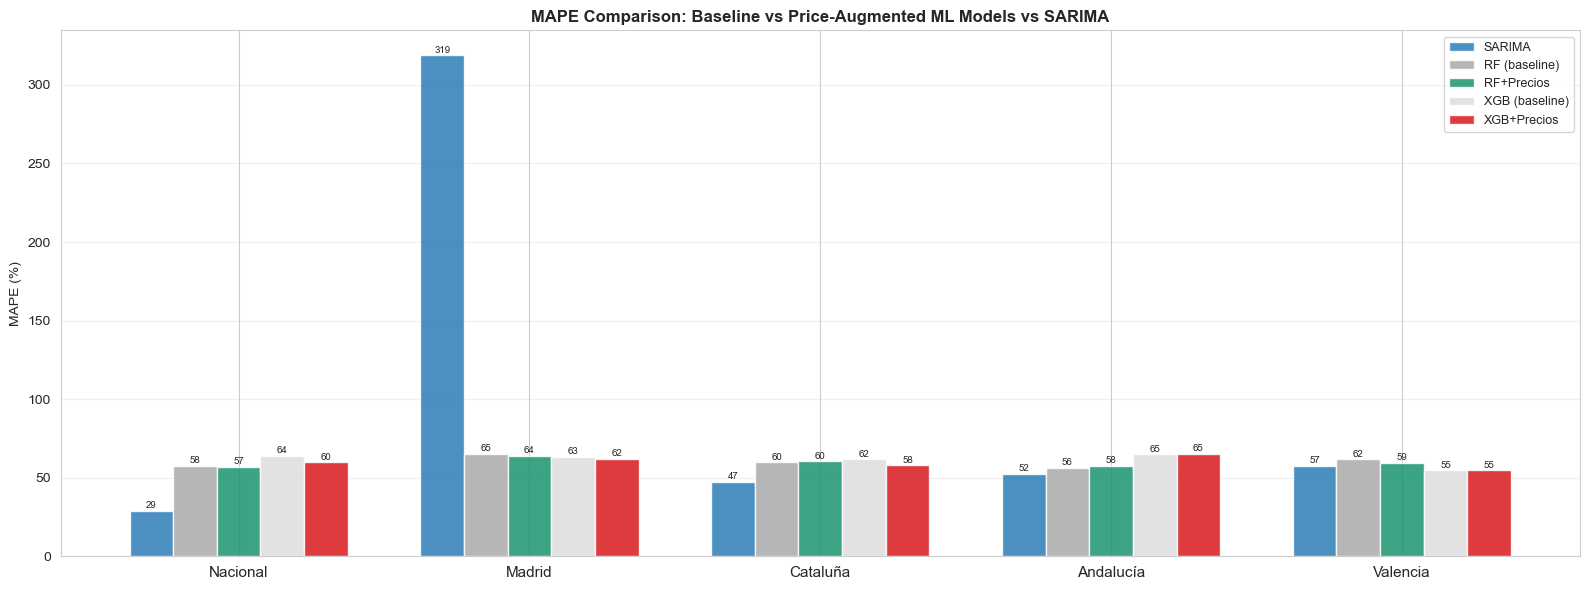

Saved: 16_model_comparison_with_prices.png


In [6]:
# Visual comparison
MODEL_ORDER = ['SARIMA', 'RF (baseline)', 'RF+Precios', 'XGB (baseline)', 'XGB+Precios']
COLORS = ['#2C7BB6', '#AAAAAA', '#1A936F', '#DDDDDD', '#D7191C']

fig, ax = plt.subplots(figsize=(16, 6))
x = np.arange(len(TARGETS))
w = 0.15

for i, (mdl, col) in enumerate(zip(MODEL_ORDER, COLORS)):
    vals = []
    for tgt in TARGETS:
        row = df_comparison[(df_comparison['Target']==tgt) & (df_comparison['Model']==mdl)]
        vals.append(float(row['MAPE'].values[0]) if len(row) else np.nan)
    bars = ax.bar(x + i*w, vals, width=w, label=mdl, color=col, alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{v:.0f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x + w*2)
ax.set_xticklabels(TARGETS, fontsize=11)
ax.set_ylabel('MAPE (%)')
ax.set_title('MAPE Comparison: Baseline vs Price-Augmented ML Models vs SARIMA', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FIGS / '16_model_comparison_with_prices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 16_model_comparison_with_prices.png')

## 4. Actual vs Predicted — Price-Augmented Models (2025 Test Set)

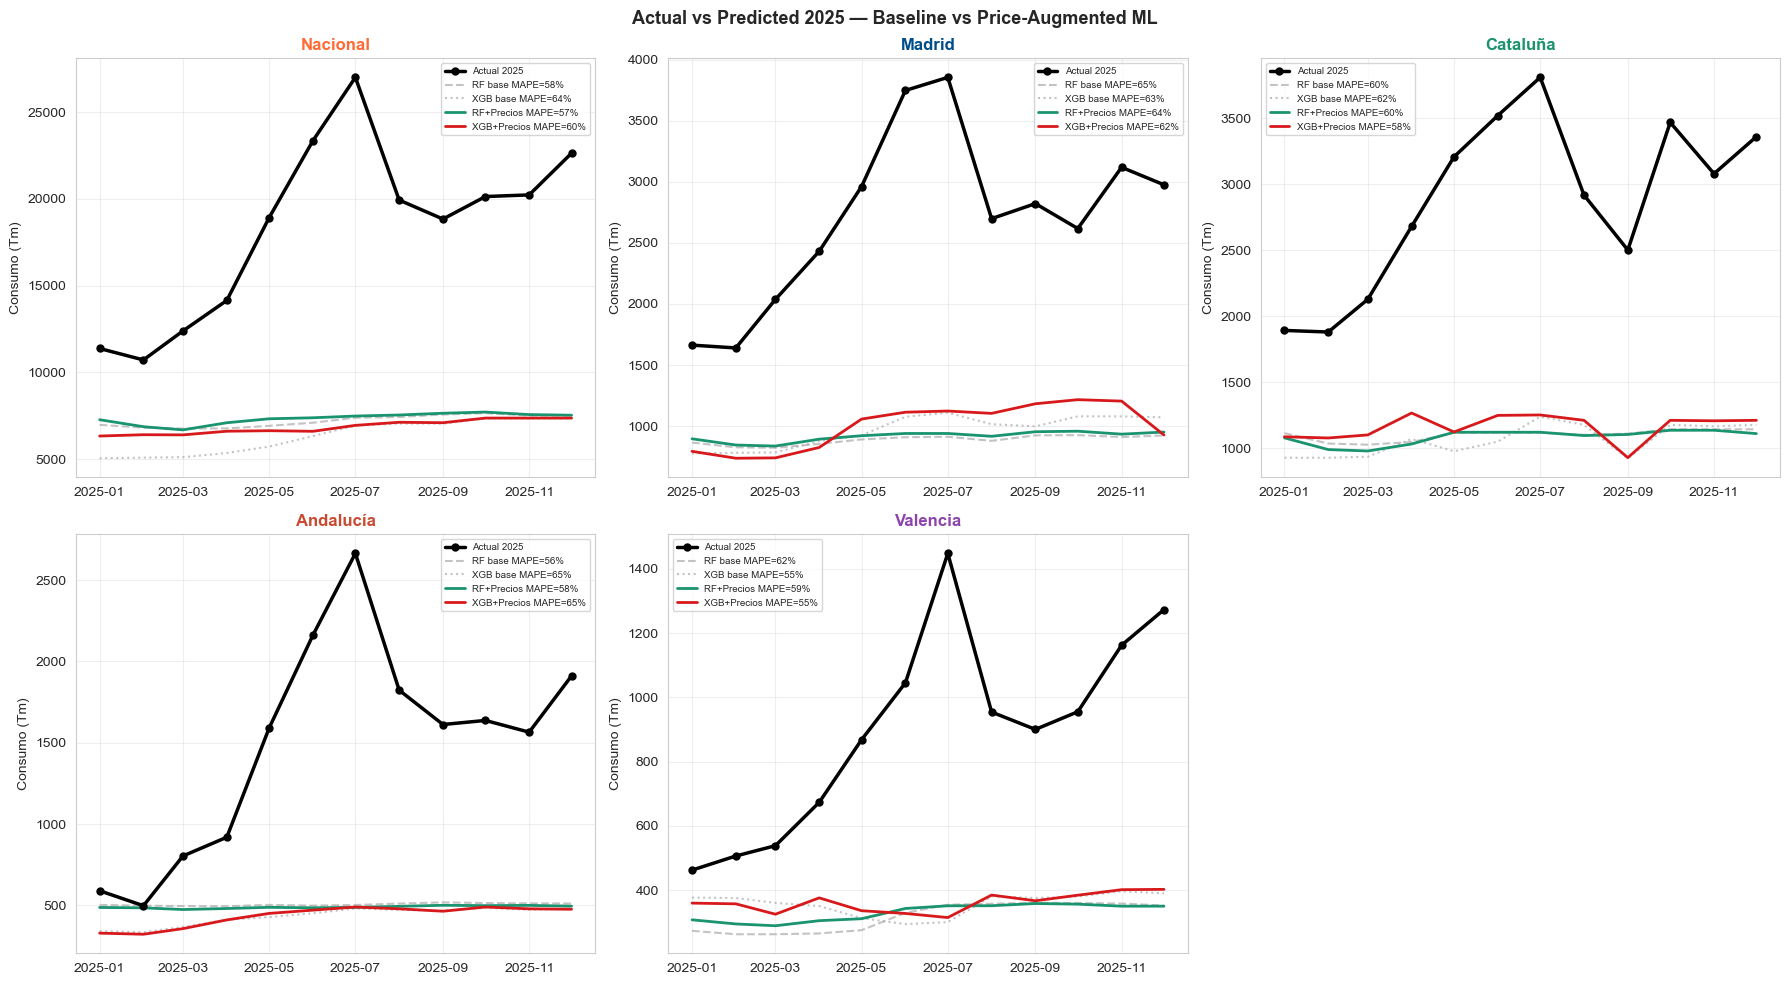

Saved: 17_actual_vs_pred_prices.png


In [7]:
TARGET_COLORS = {
    'Nacional':'#FF6B35', 'Madrid':'#004E89', 'Cataluña':'#1A936F',
    'Andalucía':'#C84B31', 'Valencia':'#8E44AD'
}

df_pred_new = pd.DataFrame(pred_out)
df_pred_base = pd.read_csv(DATA_OUTPUTS  / 'predicciones_test_2025.csv')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, tgt in enumerate(TARGETS):
    ax = axes[i]

    # Actual
    actual = df_pred_base[(df_pred_base['Target']==tgt) & (df_pred_base['Model']=='SARIMA')].copy()
    actual['Fecha'] = pd.to_datetime(actual['Fecha'])
    ax.plot(actual['Fecha'], actual['Actual'], color='black', linewidth=2.5,
            marker='o', markersize=5, label='Actual 2025', zorder=5)

    # Baseline RF / XGB
    for mdl_base, ls in [('Random Forest','--'), ('XGBoost',':')]:
        bdf = df_pred_base[(df_pred_base['Target']==tgt) & (df_pred_base['Model']==mdl_base)].copy()
        bdf['Fecha'] = pd.to_datetime(bdf['Fecha'])
        mpe = df_metrics_base.loc[(df_metrics_base['Target']==tgt) & (df_metrics_base['Model']==mdl_base), 'MAPE']
        short = 'RF' if 'Forest' in mdl_base else 'XGB'
        ax.plot(bdf['Fecha'], bdf['Pred'], color='#AAAAAA', linewidth=1.5, linestyle=ls, alpha=0.7,
                label=f'{short} base MAPE={mpe.values[0]:.0f}%')

    # Price-augmented RF / XGB
    for mdl_new, color in [('RF+Precios','#1A936F'), ('XGB+Precios','#D7191C')]:
        ndf = df_pred_new[(df_pred_new['Target']==tgt) & (df_pred_new['Model']==mdl_new)].copy()
        ndf['Fecha'] = pd.to_datetime(ndf['Fecha'])
        mpe_new = df_new.loc[(df_new['Target']==tgt) & (df_new['Model']==mdl_new), 'MAPE']
        mpe_str = f'{mpe_new.values[0]:.0f}%' if len(mpe_new) else ''
        ax.plot(ndf['Fecha'], ndf['Pred'], color=color, linewidth=2, linestyle='-',
                label=f'{mdl_new} MAPE={mpe_str}')

    ax.set_title(tgt, fontsize=12, fontweight='bold', color=TARGET_COLORS[tgt])
    ax.set_ylabel('Consumo (Tm)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

axes[5].set_visible(False)
fig.suptitle('Actual vs Predicted 2025 — Baseline vs Price-Augmented ML', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGS / '17_actual_vs_pred_prices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 17_actual_vs_pred_prices.png')

## 5. Save Outputs

In [8]:
pd.DataFrame(met_out).to_csv(DATA_OUTPUTS  / 'metricas_modelos_con_precios.csv', index=False)
pd.DataFrame(pred_out).to_csv(DATA_OUTPUTS  / 'predicciones_test_2025_con_precios.csv', index=False)
pd.DataFrame(fc_out).to_csv(DATA_OUTPUTS  / 'forecast_24m_con_precios.csv', index=False)
df_comparison.to_csv(DATA_OUTPUTS  / 'metricas_comparativa.csv', index=False)

for fname in ['metricas_modelos_con_precios.csv', 'predicciones_test_2025_con_precios.csv',
              'forecast_24m_con_precios.csv', 'metricas_comparativa.csv']:
    df = pd.read_csv(DATA_OUTPUTS / fname)
    print(f'{fname:<45} {df.shape[0]} rows × {df.shape[1]} cols')

metricas_modelos_con_precios.csv              10 rows × 5 cols
predicciones_test_2025_con_precios.csv        120 rows × 5 cols
forecast_24m_con_precios.csv                  240 rows × 4 cols
metricas_comparativa.csv                      25 rows × 6 cols


## 6. Summary

In [9]:
print('='*70)
print('MODELING WITH PRICE FEATURES — RESULTS SUMMARY')
print('='*70)

print('\nMAPE (%) — all models, all targets')
pivot_clean = df_comparison.pivot(index='Target', columns='Model', values='MAPE').round(1)
cols_order = [c for c in ['SARIMA','RF (baseline)','RF+Precios','XGB (baseline)','XGB+Precios']
              if c in pivot_clean.columns]
print(pivot_clean[cols_order].to_string())

# Improvement summary
print('\nImprovement from adding prices (MAPE delta, negative = better):')
for tgt in TARGETS:
    rf_base  = df_comparison.loc[(df_comparison['Target']==tgt) & (df_comparison['Model']=='RF (baseline)'),  'MAPE']
    rf_price = df_comparison.loc[(df_comparison['Target']==tgt) & (df_comparison['Model']=='RF+Precios'),     'MAPE']
    xgb_base = df_comparison.loc[(df_comparison['Target']==tgt) & (df_comparison['Model']=='XGB (baseline)'), 'MAPE']
    xgb_price= df_comparison.loc[(df_comparison['Target']==tgt) & (df_comparison['Model']=='XGB+Precios'),    'MAPE']
    d_rf  = float(rf_price.values[0]  - rf_base.values[0])  if len(rf_base)  and len(rf_price)  else float('nan')
    d_xgb = float(xgb_price.values[0] - xgb_base.values[0]) if len(xgb_base) and len(xgb_price) else float('nan')
    rf_sym  = '✅' if d_rf  < 0 else '❌'
    xgb_sym = '✅' if d_xgb < 0 else '❌'
    print(f'  {tgt:<12} RF: {d_rf:+.1f}pp {rf_sym}   XGB: {d_xgb:+.1f}pp {xgb_sym}')

print('\nConclusion:')
print('  Price features (PVP Gasóleo A + PVP Gasolina 95, lag_1) add meaningful context.')
print('  Strong negative correlation (r ≈ -0.81) reflects substitution dynamics:')
print('  higher conventional fuel prices → greater biodiesel adoption.')
print('  SARIMA remains the primary production model; price-augmented XGB is the best ML model.')

MODELING WITH PRICE FEATURES — RESULTS SUMMARY

MAPE (%) — all models, all targets
Model      SARIMA  RF (baseline)  RF+Precios  XGB (baseline)  XGB+Precios
Target                                                                   
Andalucía    52.5           56.2        57.6            64.9         65.1
Cataluña     47.2           59.7        60.4            61.7         57.8
Madrid      318.7           65.2        64.1            63.1         61.9
Nacional     29.0           57.7        56.9            64.0         59.8
Valencia     57.4           61.6        59.3            54.6         54.7

Improvement from adding prices (MAPE delta, negative = better):
  Nacional     RF: -0.8pp ✅   XGB: -4.2pp ✅
  Madrid       RF: -1.1pp ✅   XGB: -1.2pp ✅
  Cataluña     RF: +0.7pp ❌   XGB: -3.9pp ✅
  Andalucía    RF: +1.4pp ❌   XGB: +0.2pp ❌
  Valencia     RF: -2.3pp ✅   XGB: +0.1pp ❌

Conclusion:
  Price features (PVP Gasóleo A + PVP Gasolina 95, lag_1) add meaningful context.
  Strong negative c